# CH 5 - 5 : p-value, Statistical Significance, and Rejecting the Null Hypothesis

## Objectif pédagogique

Ce notebook transforme le concept de **p-value** en outil pratique pour évaluer un backtest.

L’idée centrale :

> On ne demande pas seulement : “ma stratégie a-t-elle gagné ?”  
> On demande : “ce gain est-il suffisamment rare sous l’hypothèse qu’elle n’a aucun talent ?”

Dans un cadre EBTA, le test statistique sert à éviter de confondre :

- un vrai edge ;
- un simple coup de chance ;
- un faux positif issu du data mining.


## 1. Le raisonnement logique

On part de l’hypothèse nulle :

$$
H_0 : \text{la stratégie n'a aucun pouvoir prédictif}
$$

Sous cette hypothèse, le rendement moyen attendu est généralement supposé égal à zéro :

$$
\mu = 0
$$

Le backtest donne une statistique observée, par exemple un rendement moyen annualisé ou quotidien.

La **p-value** répond à cette question :

$$
p\text{-value} = P(\text{obtenir un résultat au moins aussi bon que celui observé} \mid H_0)
$$

Donc :

- p-value élevée : le résultat n’est pas surprenant si la stratégie n’a aucun talent ;
- p-value faible : le résultat est rare sous $H_0$, donc $H_0$ devient difficile à croire.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf, sqrt, exp, pi

def normal_pdf(x, mu=0, sigma=1):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def normal_cdf(x, mu=0, sigma=1):
    z = (x - mu) / (sigma * sqrt(2))
    return 0.5 * (1 + erf(z))

def one_tailed_p_value(observed, mu=0, sigma=1):
    return 1 - normal_cdf(observed, mu, sigma)

mu_h0 = 0
sigma_sampling = 1
observed_statistic = 1.64  # environ p = 0.05 en test unilatéral

p_value = one_tailed_p_value(observed_statistic, mu_h0, sigma_sampling)
p_value

0.050502583474103746

## 2. Visualiser la p-value

Graphiquement, la p-value correspond à l’aire à droite du résultat observé.

Plus le résultat observé est loin dans la queue droite de la distribution, plus l’aire restante est petite.

Dans un test unilatéral positif en trading, on regarde généralement la queue droite, car on cherche à savoir si la stratégie gagne plus que ce que le hasard pourrait produire.


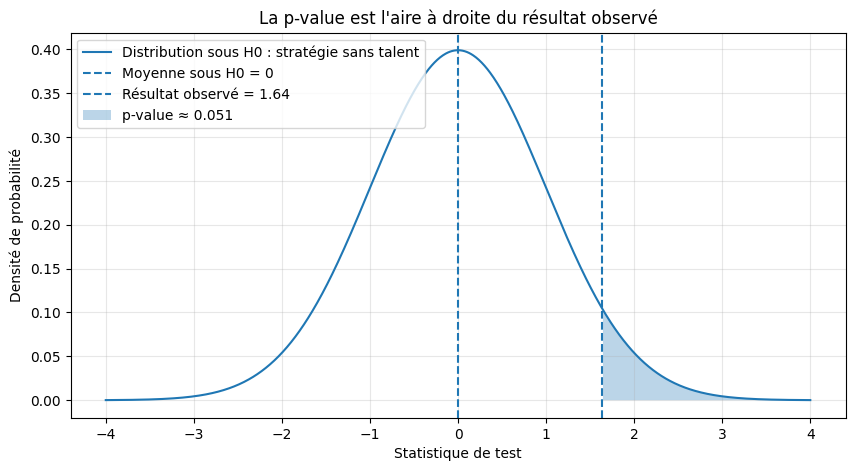

In [2]:
x = np.linspace(-4, 4, 1000)
y = normal_pdf(x, mu_h0, sigma_sampling)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label="Distribution sous H0 : stratégie sans talent")
plt.axvline(mu_h0, linestyle="--", label="Moyenne sous H0 = 0")
plt.axvline(observed_statistic, linestyle="--", label=f"Résultat observé = {observed_statistic:.2f}")

x_tail = x[x >= observed_statistic]
y_tail = normal_pdf(x_tail, mu_h0, sigma_sampling)
plt.fill_between(x_tail, y_tail, alpha=0.3, label=f"p-value ≈ {p_value:.3f}")

plt.title("La p-value est l'aire à droite du résultat observé")
plt.xlabel("Statistique de test")
plt.ylabel("Densité de probabilité")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Décision avec le seuil alpha

Le seuil alpha est décidé avant le test.

Exemple classique :

$$
\alpha = 0.05
$$

Règle de décision :

$$
\text{si p-value} < \alpha, \text{on rejette } H_0
$$

Cela veut dire :

> Le résultat est suffisamment rare sous l’hypothèse “pas de talent” pour considérer que cette hypothèse est peu crédible.

Attention : cela ne prouve pas mathématiquement que la stratégie est bonne. Cela dit seulement que l’explication “pur hasard” est devenue improbable selon le test.


In [3]:
alpha = 0.05

decision = "Rejeter H0" if p_value < alpha else "Ne pas rejeter H0"
print(f"Statistique observée : {observed_statistic:.2f}")
print(f"p-value : {p_value:.4f}")
print(f"alpha : {alpha}")
print(f"Décision : {decision}")

Statistique observée : 1.64
p-value : 0.0505
alpha : 0.05
Décision : Ne pas rejeter H0


## 4. Exemple trading simple

Imaginons une stratégie qui produit des rendements quotidiens.

Sous $H_0$, on suppose que sa moyenne réelle est égale à zéro.

On va simuler :

- une stratégie sans edge ;
- une stratégie avec un petit edge ;
- puis comparer les p-values.


In [23]:
rng = np.random.default_rng(42)

def simulate_strategy_returns(n_days=252, daily_edge=0.0, daily_vol=0.01):
    return rng.normal(loc=daily_edge, scale=daily_vol, size=n_days)

def test_mean_return(returns):
    n = len(returns)
    sample_mean = np.mean(returns)
    sample_std = np.std(returns, ddof=1)
    standard_error = sample_std / np.sqrt(n)
    z_score = sample_mean / standard_error
    p = one_tailed_p_value(z_score)
    return sample_mean, sample_std, z_score, p

returns_no_edge = simulate_strategy_returns(daily_edge=0.0)
returns_with_edge = simulate_strategy_returns(daily_edge=0.001)

for name, returns in [
    ("Stratégie sans edge", returns_no_edge),
    ("Stratégie avec edge", returns_with_edge),
]:
    mean, std, z, p = test_mean_return(returns)
    annualized_mean = mean * 252
    print(name)
    print(f"  Moyenne quotidienne : {mean:.5f}")
    print(f"  Moyenne annualisée approx. : {annualized_mean:.2%}")
    print(f"  z-score : {z:.2f}")
    print(f"  p-value : {p:.4f}")
    print(f"  Décision à alpha=0.05 : {'Rejeter H0' if p < 0.05 else 'Ne pas rejeter H0'}")
    print()

Stratégie sans edge
  Moyenne quotidienne : -0.00048
  Moyenne annualisée approx. : -12.19%
  z-score : -0.82
  p-value : 0.7936
  Décision à alpha=0.05 : Ne pas rejeter H0

Stratégie avec edge
  Moyenne quotidienne : 0.00122
  Moyenne annualisée approx. : 30.86%
  z-score : 1.97
  p-value : 0.0243
  Décision à alpha=0.05 : Rejeter H0



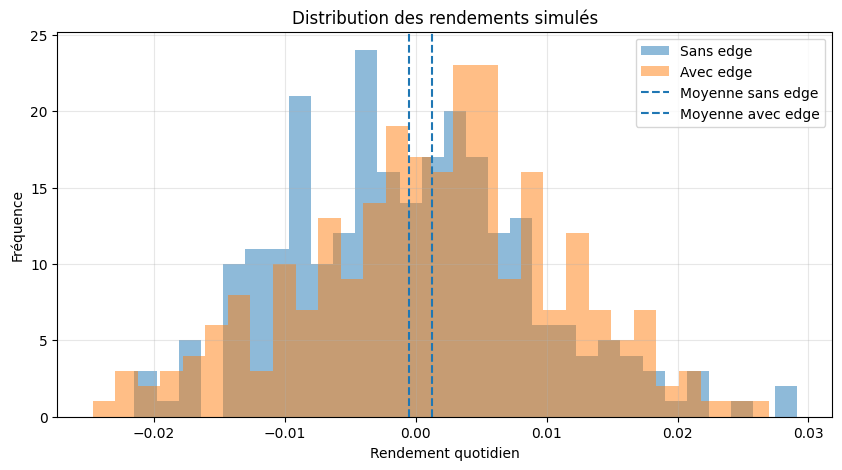

In [24]:
plt.figure(figsize=(10, 5))
plt.hist(returns_no_edge, bins=30, alpha=0.5, label="Sans edge")
plt.hist(returns_with_edge, bins=30, alpha=0.5, label="Avec edge")
plt.axvline(np.mean(returns_no_edge), linestyle="--", label="Moyenne sans edge")
plt.axvline(np.mean(returns_with_edge), linestyle="--", label="Moyenne avec edge")
plt.title("Distribution des rendements simulés")
plt.xlabel("Rendement quotidien")
plt.ylabel("Fréquence")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Le piège des p-values limites

Une p-value de 0,049 peut faire rejeter $H_0$, mais elle reste fragile.

La différence entre 0,049 et 0,051 n’est pas une frontière magique dans la réalité du marché.

C’est pourquoi un trader EBTA doit regarder :

- la p-value ;
- la taille de l’effet ;
- la stabilité du résultat ;
- le nombre de règles testées ;
- les coûts de transaction ;
- la cohérence économique ou comportementale de l’edge.


## 6. Le piège du data mining

Si tu testes une seule stratégie avec $\alpha = 0.05$, le risque de faux positif est de 5 % sous $H_0$.

Mais si tu testes 1 000 stratégies sans edge, environ 5 % peuvent paraître significatives par hasard.

$$
1000 \times 0.05 = 50
$$

Cela signifie qu’en data mining, tu peux trouver des stratégies avec p-value < 0,05 simplement parce que tu as beaucoup cherché.


In [25]:
n_rules = 1000
n_days = 252
alpha = 0.05

p_values = []

for _ in range(n_rules):
    returns = simulate_strategy_returns(n_days=n_days, daily_edge=0.0, daily_vol=0.01)
    _, _, _, p = test_mean_return(returns)
    p_values.append(p)

p_values = np.array(p_values)
false_positives = np.sum(p_values < alpha)

print(f"Nombre de règles testées : {n_rules}")
print(f"Seuil alpha : {alpha}")
print(f"Nombre de faux positifs p < alpha : {false_positives}")
print(f"Proportion : {false_positives / n_rules:.2%}")

Nombre de règles testées : 1000
Seuil alpha : 0.05
Nombre de faux positifs p < alpha : 54
Proportion : 5.40%


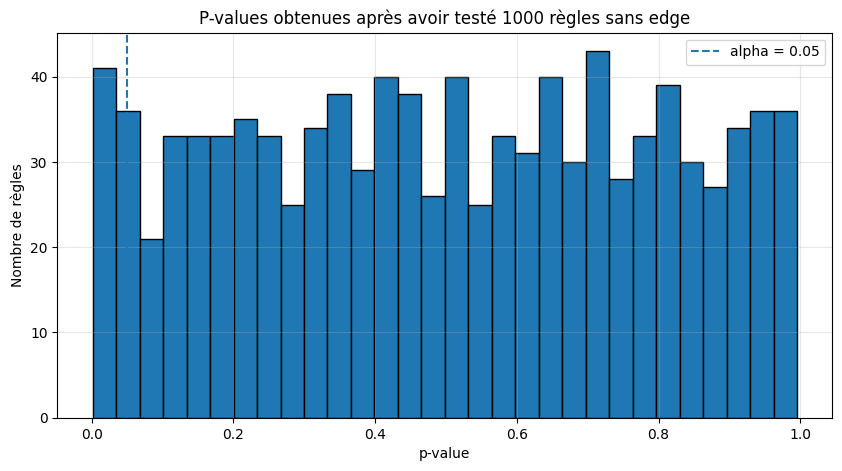

In [26]:
plt.figure(figsize=(10, 5))
plt.hist(p_values, bins=30, edgecolor="black")
plt.axvline(alpha, linestyle="--", label=f"alpha = {alpha}")
plt.title("P-values obtenues après avoir testé 1000 règles sans edge")
plt.xlabel("p-value")
plt.ylabel("Nombre de règles")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Correction simple : Bonferroni

Une correction très simple consiste à diviser alpha par le nombre de tests :

$$
\alpha_{corrigé} = \frac{\alpha}{m}
$$

où $m$ est le nombre de règles testées.

Cette correction est conservatrice, mais elle montre bien l’idée :

> Plus tu testes de règles, plus le niveau de preuve exigé doit être élevé.


In [27]:
alpha_bonferroni = alpha / n_rules
false_positives_bonferroni = np.sum(p_values < alpha_bonferroni)

print(f"Alpha classique : {alpha}")
print(f"Alpha Bonferroni : {alpha_bonferroni:.8f}")
print(f"Faux positifs avec alpha classique : {false_positives}")
print(f"Faux positifs avec Bonferroni : {false_positives_bonferroni}")

Alpha classique : 0.05
Alpha Bonferroni : 0.00005000
Faux positifs avec alpha classique : 54
Faux positifs avec Bonferroni : 0


## 8. Interprétation façon trader EBTA

La p-value n’est pas un trophée. C’est un filtre anti-illusion.

### Mauvaise lecture

> “Ma p-value est inférieure à 0,05, donc ma stratégie est forcément bonne.”

### Meilleure lecture

> “Sous l’hypothèse que ma stratégie n’a aucun talent, un résultat aussi bon serait rare. Je peux donc envisager de rejeter l’hypothèse nulle, mais je dois encore contrôler le data mining, les frais, la robustesse et l’out-of-sample.”

### Lecture champion

> “Je ne trade pas un backtest rentable. Je trade un edge statistiquement défendable, robuste, logique, et répétable.”


## 9. Résumé final

À retenir :

1. La p-value mesure la rareté du résultat sous $H_0$.
2. Une p-value faible rend l’explication “chance pure” moins crédible.
3. Le seuil alpha fixe le niveau de rareté exigé.
4. $p < 0.05$ signifie généralement “statistiquement significatif”.
5. Une p-value élevée ne prouve pas que la stratégie est nulle ; elle indique seulement que les preuves sont insuffisantes.
6. En data mining, les p-values classiques deviennent dangereuses si elles ne sont pas ajustées.
7. Plus tu testes de règles, plus tu dois exiger une preuve forte.

## Phrase à mémoriser

> La p-value ne te dit pas que ta stratégie est bonne.  
> Elle te dit à quel point ton résultat serait surprenant si ta stratégie n’avait aucun talent.


---  

## Texte source fourni

### **CH 5 - 5 : p-value, Statistical Significance, and Rejecting the Null Hypothesis**

Cette section définit les critères de décision mathématiques qui permettent à un trader EBTA de conclure si une stratégie de trading mérite d'être exploitée ou si elle doit être jetée aux oubliettes de la chance statistique.,

#### **(AJOUT) Idées clés :**
*   **Mesure de la rareté :** La p-value est la probabilité qu'un rendement de backtest soit dû à la simple variabilité d'échantillonnage (chance) sous l'Hypothèse Nulle ($H_0$).,,
*   **Critère de signification :** Un résultat est dit "statistiquement significatif" si sa p-value est inférieure à un seuil prédéfini, généralement 0,05.,,,
*   **Conformité inversée :** Une p-value élevée indique que le résultat est conforme à $H_0$ (le hasard), tandis qu'une p-value faible indique une non-conformité.
*   **Biais du data mining :** Pour le minage de données, le seuil de 0,05 est insuffisant et doit être ajusté pour éviter les "faux positifs" massifs.,,,

#### **Référence :**
*p-value, Statistical Significance, and Rejecting the Null Hypothesis*, pages 232 à 234. (Voir aussi *Statistical Analysis*, page 171).,,

#### **Citation Directe :**
« The smaller the p-value, the more statistically significant the test result. A statistically significant result is one for which the p-value is low enough to warrant a rejection of $H_0$. » (Page 232).

#### **Vision Macro :**
L'enjeu est de ne pas "parier sur le bruit". David Aronson explique que le trader est constamment confronté à des profits passés qui semblent séduisants, mais qui n'ont aucune valeur prédictive,. La p-value agit comme un juge de paix : elle quantifie le degré de "surprise". Si le résultat est trop surprenant pour être le fruit du hasard, le trader a une base rationnelle pour engager son capital,. Sans cette rigueur, le trading n'est qu'une forme de crédulité face aux coïncidences,.

#### **Vision Micro :**
Le mécanisme de la p-value fonctionne selon une probabilité conditionnelle stricte :
1.  **Le calcul de l'aire :** Graphiquement, la p-value est la fraction de l'aire sous la courbe de la distribution d'échantillonnage (centrée sur zéro) située à droite du rendement observé.,,
2.  **L'échelle de signification :** Aronson utilise des standards conventionnels :
    *   $p \le 0,10$ : Résultat "possiblement significatif".
    *   $p \le 0,05$ : Résultat "statistiquement significatif" (standard scientifique).
    *   $p \le 0,01$ : Résultat "très significatif".
    *   $p \le 0,001$ : Résultat "hautement significatif".
3.  **La décision de rejet :** Si la p-value est inférieure au seuil (alpha), on rejette $H_0$ et on adopte l'Hypothèse Alternative ($H_A$).
4.  **Lien avec l'Erreur de Type I :** La p-value représente précisément le risque que vous prenez de rejeter $H_0$ alors qu'elle est en réalité vraie (croire au talent alors que c'est de la chance).,

#### **(AJOUT) Résumé Simplifié :**
La p-value est le "pourcentage de chance que tu sois en train de te faire avoir par un coup de bol",. Si ce pourcentage est très bas (moins de 5 %), la science t'autorise à dire que ta stratégie a probablement un vrai pouvoir de prédiction. Si c'est au-dessus, tu dois admettre que n'importe quel imbécile aurait pu obtenir le même résultat par pur hasard,.

#### **Exemples du livre pour mieux comprendre :**
*   **Le test à +3,5 % :** Une règle affiche +3,5 % de profit. Le test montre que 10 % des simulations de hasard atteignent ou dépassent ce score ($p = 0,10$). Ce n'est pas suffisant pour rejeter la chance avec certitude (Figure 5.9).,,
*   **Le cas du Data Mining :** Si vous testez 1 000 règles, environ 50 d'entre elles auront une p-value de 0,05 par pur hasard (faux positifs). Aronson montre qu'un profit de +37 % peut paraître génial ($p < 0,05$ seul), mais devenir médiocre ($p = 0,45$) une fois ajusté pour le nombre de tests effectués (Figure 6.9 & 6.10).,,,

#### **Actions Concrètes :**
*   **Fixer le seuil alpha :** Déterminez votre tolérance au risque de "faux positif" (ex: 0,05) avant même de commencer le backtest.,
*   **Calculer systématiquement la p-value :** Ne regardez jamais un profit de backtest sans sa p-value associée.
*   **Se méfier des p-values "limites" :** Un score de 0,04 est fragile ; visez des p-values beaucoup plus basses si vous avez exploré beaucoup de règles.,
*   **Distinguer Signification Statistique et Pratique :** Une p-value de 0,001 sur un profit de 0,1 % signifie que le talent est réel, mais que le gain est trop faible pour couvrir les frais.

#### **(AJOUT) À retenir absolument :**
*   **La p-value n'est pas** la probabilité que votre règle soit "bonne" ; c'est la probabilité que le **hasard ait fait aussi bien**.,
*   **$p < 0,05$** est la porte d'entrée de la crédibilité scientifique.
*   Une p-value élevée est une **absence de preuve**, pas une preuve que la règle est nulle.
*   Plus la p-value est **petite**, plus vous pouvez être **confiant** dans votre rejet de la chance.
*   Le **Data Mining** rend les p-values classiques totalement mensongères.,

J'ai terminé l'analyse de la p-value et de la signification statistique selon le protocole EBTA.